## Isolation Forest Visualisation

- Baseline unsupervised ML pipeline for FDIA detection 
- Compare raw measurement windows against residual-based window representations
- Train an IF on normal system behaviour
- Score full time series to analyse anomaly behaviour over time

In [1]:
pip install pandapower


[notice] A new release of pip available: 22.2.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install seaborn pandas


[notice] A new release of pip available: 22.2.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install scikit-learn


[notice] A new release of pip available: 22.2.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import json
import numpy as np
import pandapower as pp
import pandapower.networks as pn
import pandas as pd
import matplotlib.pyplot as plt
import pandapower.plotting.plotly as pplot
import seaborn as sns 
import sys
from sklearn.ensemble import IsolationForest
from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))
from src.simulation import load_test_case
from src.time_series import run_time_series
from src.time_series import inject_fdi_time_series
from src.simulation import load_test_case, build_dc_measurement_model, simulate_measurements
import src.state_estimation
from src.state_estimation import wls_estimate, compute_residuals, state_error, run_wls_time_series
from src.attacks import standard_FDIA, random_attack, stealth_FDIA
from src.ml.dataset_builder import build_raw_window_dataset, build_residual_window_dataset
from src.ml.isolation_forest import train_isolation_forest, compute_anomaly_scores
from src.ml.training_sets import build_normal_training_set



In [5]:
test_case = "case9"
T = 1000
seed = 42

q_noise_std = 0.01
p_noise_std = 0.00
meas_noise_std = 0.04

attack_type = "stealth"
start = 300
end = 500
attacked_indices = None
shift = 0.1
scale = 0.05
alpha = 0.05

rng = np.random.default_rng(seed)

In [6]:
net = load_test_case(test_case)

Z_clean, X_true, convergence_mask, H = run_time_series(
    net=net,
    T=T,
    p_noise_std=p_noise_std,
    q_noise_std=q_noise_std,
    meas_noise_std=meas_noise_std,
    rng=rng,
    seed=seed,
)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba 

H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


...

H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba 

H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)


In [7]:
if attack_type is None:
    Z = Z_clean.copy()
    attack_mask = np.zeros(T, dtype=int)
else:
    attacked_idx_arr = None if attacked_indices is None else np.asarray(attacked_indices, dtype=int)

    Z, attack_mask = inject_fdi_time_series(
        Z=Z_clean,
        H=H,
        attack_type=attack_type,
        attacked_indices=attacked_idx_arr,
        alpha=alpha,
        start=start,
        end=end,
        rng=rng,
        shift=shift,
        scale=scale,
        seed=seed,
    )


In [8]:
# Baseline A: raw measurement windows
window_size = 20
stride = 1

X, metadata = build_raw_window_dataset(
    Z=Z,
    window_size=window_size,
    convergence_mask=convergence_mask,
    stride=stride,
)

X_train, train_metadata = build_normal_training_set(
    X,
    metadata,
    window_size,
    attack_mask,
)

model, model_metadata = train_isolation_forest(X_train)

results = compute_anomaly_scores(
    model=model,
    X=X,
    window_metadata=metadata,
    attack_mask=attack_mask,
)


## Baseline A - score full time series and visualise anomaly behaviour

In [ ]:
# Score full time series
# Extract results
t = np.asarray(results["window_start_indices"])
normality_score = np.asarray(results["anomaly_score"])   # decision_function output
attack_labels = np.asarray(results["window_attack_label"])

# Convert to anomaly score
anomaly_score = -normality_score  # Higher score = more anomalous

# Compute training anomaly scores
train_normality = model.decision_function(X_train)
train_anomaly_score = -train_normality

# Define threshold (baseline choice)
threshold = np.percentile(train_anomaly_score, 95)

print(f"Anomaly threshold (95th percentile of training): {threshold:.4f}")

binary_detected = (anomaly_score > threshold).astype(int)

## Temporal anomaly score plot

Anomaly threshold (95th percentile of training): -0.0467


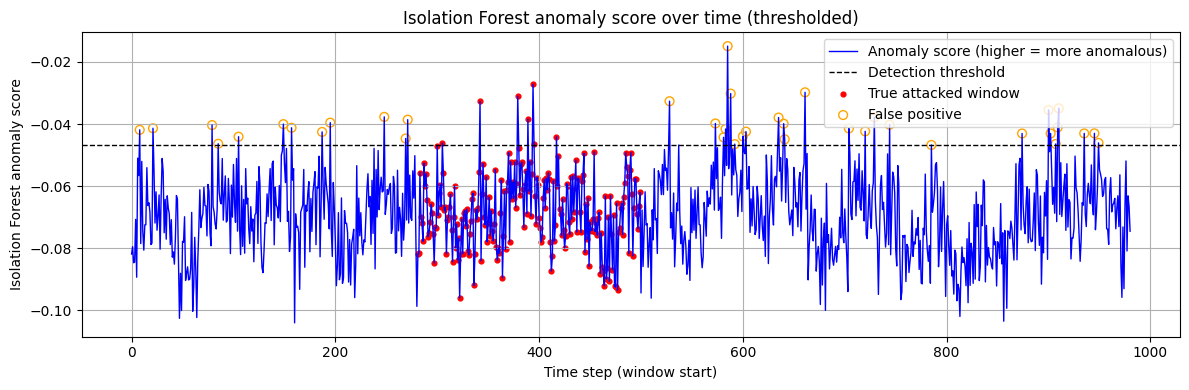

In [ ]:
#Main time series plot
plt.figure(figsize=(12, 4))

plt.plot(
    t,
    anomaly_score,
    label="Anomaly score (higher = more anomalous)",
    color="blue",
    linewidth=1,
)

# Threshold line
plt.axhline(
    threshold,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Detection threshold",
)

# Highlight true attacked windows
plt.scatter(
    t[attack_labels == 1],
    anomaly_score[attack_labels == 1],
    color="red",
    s=12,
    label="True attacked window",
)

# Highlight false positives
false_positives = (binary_detected == 1) & (attack_labels == 0)
plt.scatter(
    t[false_positives],
    anomaly_score[false_positives],
    facecolors="none",
    edgecolors="orange",
    s=40,
    label="False positive",
)

plt.xlabel("Time step (window start)")
plt.ylabel("Isolation Forest anomaly score")
plt.title("Isolation Forest anomaly score over time (thresholded)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



### Score Distribution plot

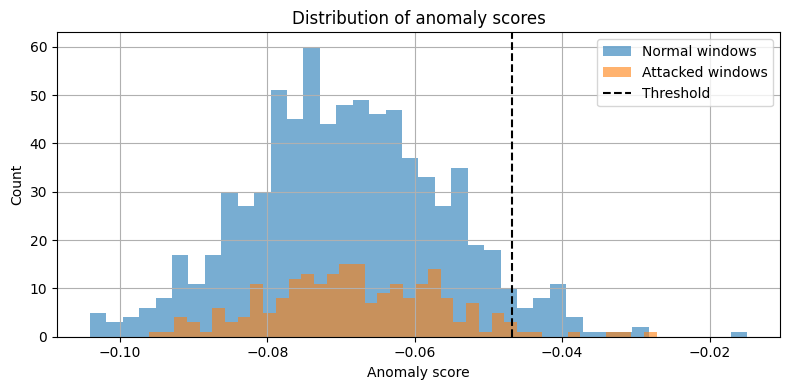

In [10]:
# Distribution plot
plt.figure(figsize=(8, 4))

plt.hist(
    anomaly_score[attack_labels == 0],
    bins=40,
    alpha=0.6,
    label="Normal windows",
)

plt.hist(
    anomaly_score[attack_labels == 1],
    bins=40,
    alpha=0.6,
    label="Attacked windows",
)

plt.axvline(
    threshold,
    color="black",
    linestyle="--",
    label="Threshold",
)

plt.xlabel("Anomaly score")
plt.ylabel("Count")
plt.title("Distribution of anomaly scores")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
# Baseline B: residual windows
window_size = 20
stride = 1
sigma = meas_noise_std  # consistent with simulation

X, metadata = build_residual_window_dataset(
    Z=Z,
    H=H,
    sigma=sigma,
    window_size=window_size,
    convergence_mask=convergence_mask,
    stride=stride,
)

X_train, train_metadata = build_normal_training_set(
   X,
    metadata,
    window_size,
    attack_mask,
)

model, model_metadata = train_isolation_forest(X_train)

results = compute_anomaly_scores(
    model=model,
    X=X,
    window_metadata=metadata,
    attack_mask=attack_mask,
)


##  Baseline B - Score full time series and visualise anomaly behaviour

In [15]:
# Score full time series

# Extract results
t = np.asarray(results["window_start_indices"])
normality_score = np.asarray(results["anomaly_score"])   # decision_function output
attack_labels = np.asarray(results["window_attack_label"])

# Convert to anomaly score
anomaly_score = -normality_score  # Higher score = more anomalous

# Compute training anomaly scores (threshold)
train_normality = model.decision_function(X_train)
train_anomaly_score = -train_normality

# Define threshold (baseline choice)
threshold = np.percentile(train_anomaly_score, 95)

print(f"Anomaly threshold (95th percentile of training): {threshold:.4f}")

binary_detected = (anomaly_score > threshold).astype(int)

Anomaly threshold (95th percentile of training): 0.0009


## Temporal anomaly score plot

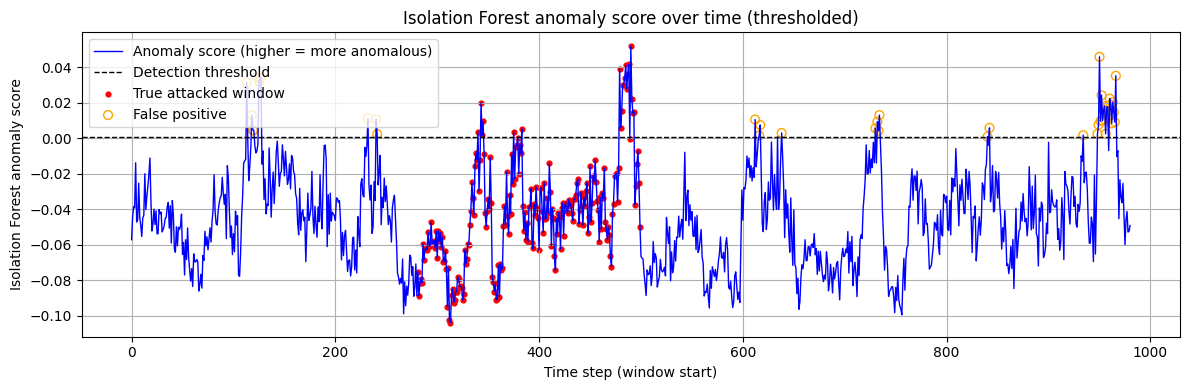

In [14]:
#Main time series plot
plt.figure(figsize=(12, 4))

plt.plot(
    t,
    anomaly_score,
    label="Anomaly score (higher = more anomalous)",
    color="blue",
    linewidth=1,
)

# Threshold line
plt.axhline(
    threshold,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Detection threshold",
)

# Highlight true attacked windows
plt.scatter(
    t[attack_labels == 1],
    anomaly_score[attack_labels == 1],
    color="red",
    s=12,
    label="True attacked window",
)

# Highlight false positives
false_positives = (binary_detected == 1) & (attack_labels == 0)
plt.scatter(
    t[false_positives],
    anomaly_score[false_positives],
    facecolors="none",
    edgecolors="orange",
    s=40,
    label="False positive",
)

plt.xlabel("Time step (window start)")
plt.ylabel("Isolation Forest anomaly score")
plt.title("Isolation Forest anomaly score over time (thresholded)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



### Score distribution plot

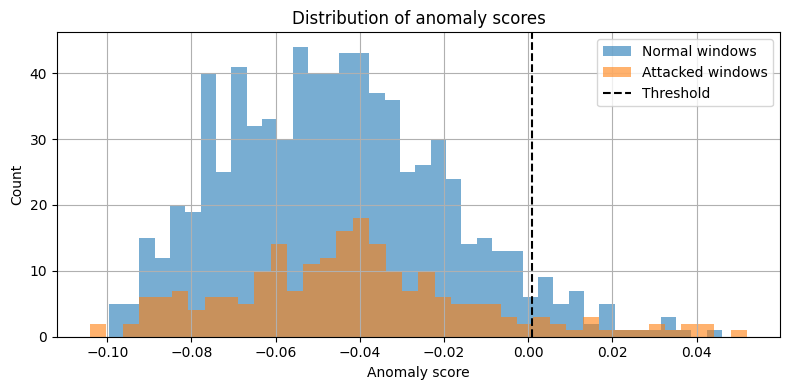

In [13]:
# Distribution plot
plt.figure(figsize=(8, 4))

plt.hist(
    anomaly_score[attack_labels == 0],
    bins=40,
    alpha=0.6,
    label="Normal windows",
)

plt.hist(
    anomaly_score[attack_labels == 1],
    bins=40,
    alpha=0.6,
    label="Attacked windows",
)

plt.axvline(
    threshold,
    color="black",
    linestyle="--",
    label="Threshold",
)

plt.xlabel("Anomaly score")
plt.ylabel("Count")
plt.title("Distribution of anomaly scores")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Results Summary

- Raw measurement windows (baseline A) detect the attack but exhibit higher score variability during normal operation, therefore more false positives.
- Residual based windows (baseline B) detect the attack period more clearly in time, with fewer detections outside the true attack interval.
- The distribution of anomaly scores for residual windows shows a clearer seperation between normal behaviour and attacked behaviour.
- Residual features captures violations of the physical system model, which makes them more sensitive to stealth FDIA than raw measurements.
- These results justify using residual-based window representations as the primary feature set for futher experimentation. 